In [10]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

^C
Note: you may need to restart the kernel to use updated packages.


   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 0.5/350.9 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 1.3/350.9 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 2.9/350.9 MB 5.2 MB/s eta 0:01:07
    --------------------------------------- 6.6/350.9 MB 8.8 MB/s eta 0:00:40
   - -------------------------------------- 10.0/350.9 MB 10.3 MB/s eta 0:00:33
   - -------------------------------------- 14.9/350.9 MB 12.7 MB/s eta 0:00:27
   -- ------------------------------------- 19.9/350.9 MB 14.6 MB/s eta 0:00:23
   -- ------------------------------------- 24.9/350.9 MB 15.8 MB/s eta 0:00:21
   --- ------------------------------------ 29.9/350.9 MB 16.5 MB/s eta 0:00:20
   --- ------------------------------------ 32.8/350.9 MB 16.8 MB/s eta 0:00:19
   ---- ----------------------------------- 35.7/350.9 MB 15.9 MB/s eta 0:00:20
   ---- ----------------------------------- 38.0/350.9 MB

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
streamlit 1.41.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


# 📊 Jalon 1 : Analyse Exploratoire des Données (EDA) & Visualisation (Squelette Étudiant)

Ce notebook est dédié à la découverte de relations clés et à l'analyse visuelle de nos données. À partir du jeu de données propre généré précédemment, nous allons enrichir nos variables explicatives et appeler les fonctions de notre module de visualisation `src.utils_viz` pour générer des graphiques professionnels.

### 1. Importation des packages et configuration du style

In [ ]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.append(os.path.abspath('..'))
from src import data_clean as dc
from src import utils_viz as uv

# Activation de la charte graphique personnalisée du projet
uv.set_custom_style(theme='light')
%matplotlib inline

🎨 Charte graphique 'light' initialisée avec succès.


In [ ]:
# Chargement du dataset propre
df = pd.read_csv('../data/processed/owid-monkeypox-data_clean.csv')
df['date'] = pd.to_datetime(df['date'])
df.head()

,country,date,total_cases,total_deaths,daily_new_cases,daily_new_deaths
0,Andorra,2022-07-25,2.0,0.0,2.0,0.0
1,Andorra,2022-07-26,3.0,0.0,1.0,0.0
2,Andorra,2022-07-27,3.0,0.0,0.0,0.0
3,Andorra,2022-07-28,3.0,0.0,0.0,0.0
4,Andorra,2022-07-29,3.0,0.0,0.0,0.0


### 2. Ingénierie de variables temporelles

**À faire par l'étudiant :**
Appliquez la fonction `feature_engineering` de `src.data_clean` pour enrichir votre DataFrame en caractéristiques de temps classiques .

In [ ]:
df_feat = df.copy()

df_feat['year'] = df_feat['date'].dt.year
df_feat['month'] = df_feat['date'].dt.month
df_feat['year_month'] = df_feat['date'].dt.to_period('M').astype(str)
df_feat['dayofweek'] = df_feat['date'].dt.dayofweek

df_feat.head()

,country,date,total_cases,total_deaths,daily_new_cases,daily_new_deaths,year,month,year_month,dayofweek
0,Andorra,2022-07-25,2.0,0.0,2.0,0.0,2022,7,2022-07,0
1,Andorra,2022-07-26,3.0,0.0,1.0,0.0,2022,7,2022-07,1
2,Andorra,2022-07-27,3.0,0.0,0.0,0.0,2022,7,2022-07,2
3,Andorra,2022-07-28,3.0,0.0,0.0,0.0,2022,7,2022-07,3
4,Andorra,2022-07-29,3.0,0.0,0.0,0.0,2022,7,2022-07,4


### 3. Visualisations Professionnelles

#### A. Profils d'évolution et tendances

**À faire par l'étudiant :**
Appliquez la fonction `plot_generic_trends` de votre module `src.utils_viz` pour tracer l'évolution de la valeur par rapport au temps.

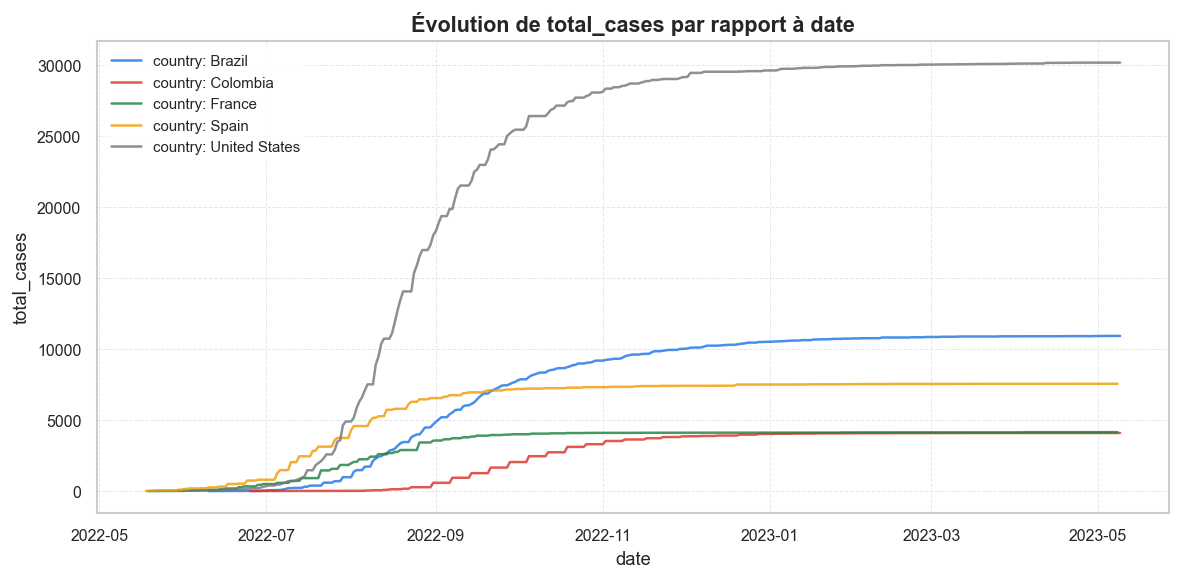

In [21]:
top_5_countries = (
    df_feat.groupby('country')['total_cases']
    .max()
    .sort_values(ascending=False)
    .head(5)
    .index
)

df_top5 = df_feat[df_feat['country'].isin(top_5_countries)]

fig1 = uv.plot_generic_trends(
    df_top5,
    x_col='date',
    y_col='total_cases',
    group_col='country'
)

plt.show()

#### B. Répartition mondiale des cas cumulés de mpox par pays

Cette carte permet de visualiser la répartition géographique des cas cumulés de mpox.  
Elle est pertinente car le dataset contient une dimension spatiale avec une variable pays.  
Contrairement à un simple tableau, la carte facilite l’identification rapide des zones les plus touchées et permet de comparer visuellement l’intensité de l’épidémie entre les pays.

In [18]:
import plotly.express as px

# On récupère le nombre maximum de cas cumulés par pays
map_data = (
    df_feat.groupby("country", as_index=False)["total_cases"]
    .max()
    .sort_values(by="total_cases", ascending=False)
)

fig = px.choropleth(
    map_data,
    locations="country",
    locationmode="country names",
    color="total_cases",
    hover_name="country",
    color_continuous_scale="Reds",
    title="Répartition mondiale des cas cumulés de mpox par pays"
)

fig.update_layout(
    title_x=0.5,
    geo=dict(showframe=False, showcoastlines=True)
)

fig.show()

#### C. Carte animée de la propagation du mpox

**À faire par l'étudiant :**
Générez un nuage de points de la relation heure vs valeur en colorant les points selon la variable `dayofweek`, en utilisant votre fonction `plot_bivariate_scatter`.

In [24]:
import plotly.express as px

# Préparation des données mensuelles par pays
map_time_data = (
    df_feat.groupby(["country", "year_month"], as_index=False)
    .agg({
        "total_cases": "max",
        "daily_new_cases": "sum"
    })
)

# Correction des noms de pays pour Plotly
map_time_data["country_map"] = map_time_data["country"].str.replace("_", " ")

# Conversion du mois en date pour garantir l'ordre chronologique
map_time_data["year_month_date"] = pd.to_datetime(map_time_data["year_month"])

# Tri chronologique
map_time_data = map_time_data.sort_values("year_month_date")

fig = px.choropleth(
    map_time_data,
    locations="country_map",
    locationmode="country names",
    color="total_cases",
    hover_name="country",
    hover_data={
        "total_cases": True,
        "daily_new_cases": True,
        "year_month": True,
        "country_map": False
    },
    animation_frame="year_month",
    color_continuous_scale="Reds",
    title="Propagation du mpox dans le monde au fil du temps"
)

fig.update_layout(
    title_x=0.5,
    geo=dict(
        showframe=False,
        showcoastlines=True
    )
)

fig.show()

### 4. Synthèse des observations clés
Sur la base de vos figures, listez les **insights majeurs** observés sur le comportement de vos variables.